Exercise Graph 4

In [23]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [24]:
class AgentState(TypedDict):
    num1: int
    num2: int 
    operation: str
    result: int
    num3: int
    num4: int
    operation2: str
    result2: int

In [25]:
def adder(state: AgentState) -> AgentState:
    """This node adds two numbers."""

    state["result"] = state["num1"] + state["num2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts two numbers."""

    state["result"] = state["num1"] - state["num2"]
    return state

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node phase of the graph"""

    if state["operation"] == "+":
        return "addition_operation" 
    elif state["operation"] == "-":
        return "subtraction_operation"
    
def adder2(state: AgentState) -> AgentState:
    """This node adds two numbers."""

    state["result2"] = state["num3"] + state["num4"]
    return state

def subtractor2(state: AgentState) -> AgentState:
    """This node subtracts two numbers."""

    state["result2"] = state["num3"] - state["num4"]
    return state

def decide_next_node2(state: AgentState) -> AgentState:
    """This node will select the next node phase of the graph"""

    if state["operation2"] == "+":
        return "addition_operation2" 
    elif state["operation2"] == "-":
        return "subtraction_operation2"

In [26]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router",  lambda state: state)

graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)
graph.add_node("router2", lambda state: state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node",
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")  

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2",
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

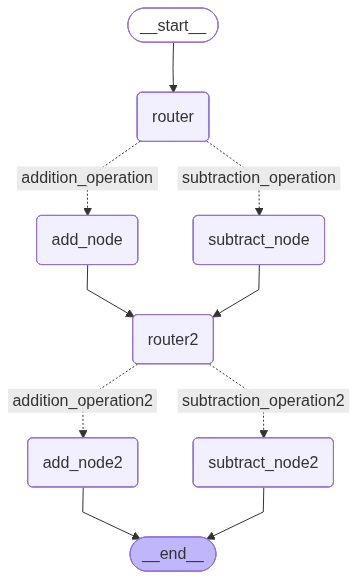

In [27]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [28]:
initial_state = {'num1': 10, 'num2': 5, 'operation': '+', 'num3': 7, 'num4': 3, 'operation2': '-'}
app.invoke(initial_state)

{'num1': 10,
 'num2': 5,
 'operation': '+',
 'result': 15,
 'num3': 7,
 'num4': 3,
 'operation2': '-',
 'result2': 4}